In [4]:
import pybamm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
import dfols
import signal
from scipy.integrate import solve_ivp
from scipy.fft import fft, fftfreq, fftshift
from scipy.signal import savgol_filter
from scipy.signal import find_peaks
from scipy import interpolate, integrate
from stopit import threading_timeoutable as timeoutable
from scipy.optimize import differential_evolution, curve_fit, minimize
from scipy.optimize import Bounds, LinearConstraint, NonlinearConstraint
import os, sys
sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath("__file__"))))
from batfuns import *
plt.rcParams = set_rc_params(plt.rcParams)
import winsound
from pybamm import exp, constants, Parameter
import pickle
from tqdm import tqdm

eSOH_DIR = "../data/esoh_R/"
oCV_DIR = "../data/ocv/"
cyc_DIR = "../data/cycling/"
fig_DIR = "../figures/figures_model/"
res_DIR = "../data/results_model/"
resistance_DIR = "../data/resistance/"
# %matplotlib widget

In [5]:
def Un(sto):
    u_eq = (
        0.063
        + 0.8 * math.exp(-75 * (sto + 0.007))
        - 0.0120 * math.tanh((sto - 0.127) / 0.016)
        - 0.0118 * math.tanh((sto - 0.155) / 0.016)
        - 0.0035 * math.tanh((sto - 0.220) / 0.020)
        - 0.0095 * math.tanh((sto - 0.190) / 0.013)
        - 0.0145 * math.tanh((sto - 0.490) / 0.020)
        - 0.0800 * math.tanh((sto - 1.030) / 0.055)
    )

    return u_eq

def Up(sto):
    u_eq = (
        4.3452
        - 1.6518 * sto
        + 1.6225 * (sto ** 2)
        - 2.0843 * (sto ** 3)
        + 3.5146 * (sto ** 4)
        - 2.2166 * (sto ** 5)
        - 0.5623 * math.exp(109.451 * sto - 100.006)
    )

    return u_eq

In [6]:
def OCP1(X,Q):
    ocp = Up(X[3]-Q/X[2])-Un(X[1]+Q/X[0])
    return ocp

def fitfunc1(x,Qdata,Vdata,R,Crate):
  model = np.concatenate([
         [OCP1(x,Q)+R*Crate*5]
        for Q in Qdata
    ]
  )
  Vd = Vdata
  Vs = model
  error = Vd-Vs
  out = np.linalg.norm(error)/np.sqrt(len(Vd))
  return out

def OCP2(X,Q):
    ocp = Up(X[3]+Q/X[2])-Un(X[1]-Q/X[0])
    return ocp

def fitfunc2(x,Qdata,Vdata,R,Crate):
  model = np.concatenate([
         [OCP2(x,Q)+R*Crate*5]
        for Q in Qdata
    ]
  )
  Vd = Vdata
  Vs = model
  error = Vd-Vs
  out = np.linalg.norm(error)/np.sqrt(len(Vd))
  return out

In [7]:
cell = 1

In [8]:
cyc_no = 240
cell_no,dfe,dfe_0,dfo_0,N,N_0 = load_data(cell,eSOH_DIR,oCV_DIR)
cyc_data_raw1 = pd.read_csv(cyc_DIR+'cycling_data_cell_'+cell_no+'.csv')
cyc_data_raw1['Cycle number'] = cyc_data_raw1['Cycle number'] + 1
cyc_data_raw = cyc_data_raw1[ cyc_data_raw1['Cycle number'] == cyc_no ]
cyc_data = cyc_data_raw.reset_index(drop=True)
t_c1 = cyc_data['Time [s]']-cyc_data['Time [s]'][0]
t_c1 = t_c1.values
I_c1 = cyc_data['Current [mA]']/1000
I_c1 = I_c1.values
V_c1 = cyc_data['Voltage [V]']
V_c1 = V_c1.values
E_c1 = cyc_data["Expansion [mu m]"]
E_c1 = E_c1.values
Q_c1 = cyc_data["Q [Ah]"]
Q_c1 = Q_c1.values
Q_c1 = Q_c1 - Q_c1[0]

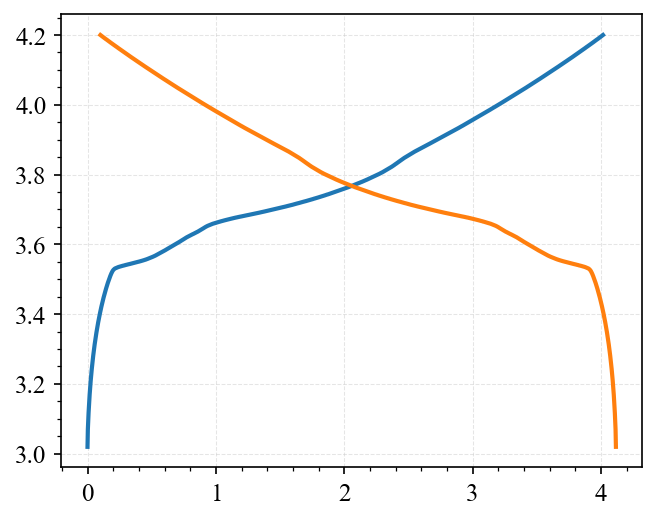

In [9]:
idx_I = np.where((np.diff(I_c1)<-0.02) & (I_c1[:-1]>0) & (I_c1[:-1]<2))[0] 
# idx_I = idx_I[idx_I>50]
t = t_c1[:idx_I[0]]
V = V_c1[:idx_I[0]]
I = I_c1[:idx_I[0]]
E = E_c1[:idx_I[0]]-E_c1[0]
Q = Q_c1[:idx_I[0]]
Qmax = max(cyc_data["Q [Ah]"]-cyc_data["Q [Ah]"].iloc[0])
Qi = integrate.cumtrapz(I,t, initial=0)/3600 #Ah
Q1 = Q
Q2 = Qmax - Q1

fig, ax = plt.subplots(1,1,figsize=(5,4))
ax.plot(Q1,V)
ax.plot(Q2,V)

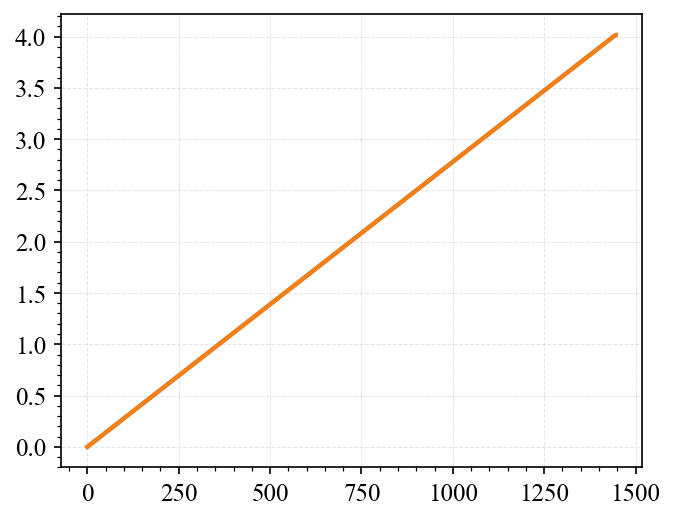

In [10]:
fig, ax = plt.subplots(1,1,figsize=(5,4))
ax.plot(Qi)
ax.plot(Q1)

In [11]:
R = dfe_0.iloc[(dfe_0['N']-cyc_no).abs().argsort()[:1]]["Rs_ave"].iloc[0]
Crate = 1/5

In [12]:
lb = [1, 0, 1, 0]
ub = [7, 1, 7, 1]
bounds = Bounds(lb, ub)
result1 = minimize(fitfunc1, [6,0.01,6,0.9], args=(Q1,V,R,0), bounds=bounds)
print(result1.x)
result2 = minimize(fitfunc2, [6,0.8,6,0.1], args=(Q2,V,R,0), bounds=bounds)
print(result2.x)

[4.9458422  0.         5.62781001 0.74855055]
[4.90788525 0.83796812 5.63702923 0.01764164]


In [13]:
# Cn1 = res1[0]
# print(Cn1)
# Cn2 = res2[0]
# print(Cn2)
# print((Cn1-Cn2)/Cn1)

In [14]:
res1 = result1.x
Cn1 = res1[0]
Vfit1 = np.concatenate([
        [OCP1(res1,Q)]
        for Q in Q1
    ]
)
res2 = result2.x
Cn2 = res2[0]
Vfit2 = np.concatenate([
        [OCP2(res2,Q)+R*Crate*5]
        for Q in Q2
    ]
)

4.945842196547404
4.907885250147472


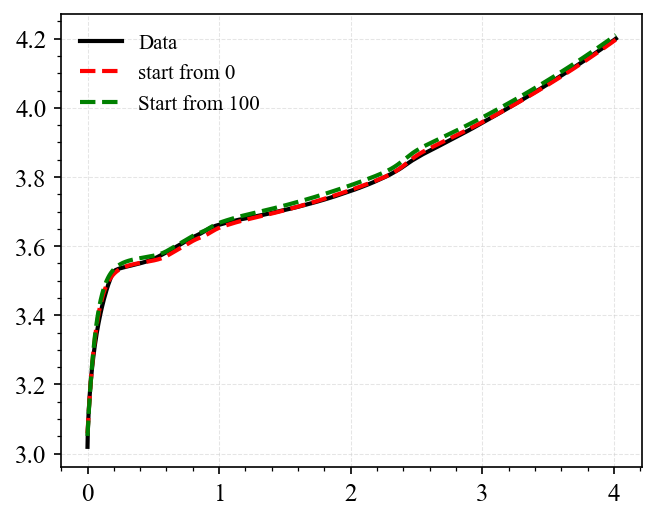

In [15]:
print(Cn1)
print(Cn2)
fig, ax = plt.subplots(1,1,figsize=(5,4))
ax.plot(Q1,V,'k')
ax.plot(Q1,Vfit1,'r--')
ax.plot(max(Q2)-Q2,Vfit2,'g--')
ax.legend(["Data","start from 0","Start from 100"])

In [16]:
def load_cycling_data_ch(cyc_data_raw1,cyc_no):
    cyc_data_raw = cyc_data_raw1[ cyc_data_raw1['Cycle number'] == cyc_no ]
    cyc_data = cyc_data_raw.reset_index(drop=True)
    t_c1 = cyc_data['Time [s]']-cyc_data['Time [s]'][0]
    t_c1 = t_c1.values
    I_c1 = cyc_data['Current [mA]']/1000
    I_c1 = I_c1.values
    V_c1 = cyc_data['Voltage [V]']
    V_c1 = V_c1.values
    E_c1 = cyc_data["Expansion [mu m]"]
    E_c1 = E_c1.values
    Q_c1 = cyc_data["Q [Ah]"]
    Q_c1 = Q_c1.values
    Q_c1 = Q_c1 - Q_c1[0]
    idx_I = np.where((np.diff(I_c1)<-0.02) & (I_c1[:-1]>0) & (I_c1[:-1]<2))[0] 
    t = t_c1[:idx_I[0]]
    V = V_c1[:idx_I[0]]
    I = I_c1[:idx_I[0]]
    E = E_c1[:idx_I[0]]-E_c1[0]
    Q = Q_c1[:idx_I[0]]
    Qmax = max(cyc_data["Q [Ah]"]-cyc_data["Q [Ah]"].iloc[0])
    Qi = integrate.cumtrapz(I,t, initial=0)/3600 #Ah
    Q1 = Q
    Q2 = Qmax - Q1
    return t,V,I,Q1,Q2


In [17]:
cell = 4
cell_no,dfe,dfe_0,dfo_0,N,N_0 = load_data(cell,eSOH_DIR,oCV_DIR)
cyc_data_raw1 = pd.read_csv(cyc_DIR+'cycling_data_cell_'+cell_no+'.csv')
cyc_data_raw1['Cycle number'] = cyc_data_raw1['Cycle number'] + 1
xa, ya, Cna, Cpa = np.array([]), np.array([]), np.array([]), np.array([])
Na = np.array([])
x0 = [6,0.01,6,0.9]
for cyc_no in tqdm(range(1,max(cyc_data_raw1['Cycle number'])+1)):
# for cyc_no in tqdm(range(1,5)):
    try:
        if cyc_no >1:
            x0 = [np.average(Cna[-10:]),np.average(xa[-10:]),np.average(Cpa[-10:]),np.average(ya[-10:])]
        t_d,V_d,I_d,Q_d1,Q_d2 = load_cycling_data_ch(cyc_data_raw1,cyc_no)
        Q_d1 = Q_d1[::2]
        Q_d2 = Q_d2[::2]
        V_d = V_d[::2]
        R = dfe_0.iloc[(dfe_0['N']-cyc_no).abs().argsort()[:1]]["Rs_ave"].iloc[0]
        Crate = 0
        result = minimize(fitfunc1, x0, args=(Q_d1,V_d,R,Crate), bounds=bounds)
        res = result.x
        Na = np.append(Na,cyc_no)
        Cna = np.append(Cna,res[0])
        xa = np.append(xa,res[1])
        Cpa = np.append(Cpa,res[2])
        ya = np.append(ya,res[3])
    except Exception as error:
        print(cyc_no)
        print(error)
df1 = pd.DataFrame({"N":Na,"Cn":Cna})

100%|██████████| 328/328 [00:34<00:00,  9.57it/s]


In [18]:
cell = 4
cell_no,dfe,dfe_0,dfo_0,N,N_0 = load_data(cell,eSOH_DIR,oCV_DIR)
cyc_data_raw1 = pd.read_csv(cyc_DIR+'cycling_data_cell_'+cell_no+'.csv')
cyc_data_raw1['Cycle number'] = cyc_data_raw1['Cycle number'] + 1
xa, ya, Cna, Cpa = np.array([]), np.array([]), np.array([]), np.array([])
Na = np.array([])
x0 = [6,0.8,6,0.1]
for cyc_no in tqdm(range(1,max(cyc_data_raw1['Cycle number'])+1)):
# for cyc_no in tqdm(range(1,5)):
    try:
        if cyc_no >1:
            x0 = [np.average(Cna[-10:]),np.average(xa[-10:]),np.average(Cpa[-10:]),np.average(ya[-10:])]
        t_d,V_d,I_d,Q_d1,Q_d2 = load_cycling_data_ch(cyc_data_raw1,cyc_no)
        Q_d1 = Q_d1[::2]
        Q_d2 = Q_d2[::2]
        V_d = V_d[::2]
        R = dfe_0.iloc[(dfe_0['N']-cyc_no).abs().argsort()[:1]]["Rs_ave"].iloc[0]
        Crate = 0
        result = minimize(fitfunc2, x0, args=(Q_d2,V_d,R,Crate), bounds=bounds)
        res = result.x
        # Cn = res[0]
        # Na.append(cyc_no)
        # Cna.append(Cn)
        Na = np.append(Na,cyc_no)
        Cna = np.append(Cna,res[0])
        xa = np.append(xa,res[1])
        Cpa = np.append(Cpa,res[2])
        ya = np.append(ya,res[3])
    except Exception as error:
        print(cyc_no)
        print(error)
df2 = pd.DataFrame({"N":Na,"Cn":Cna})

100%|██████████| 328/328 [00:20<00:00, 15.90it/s]


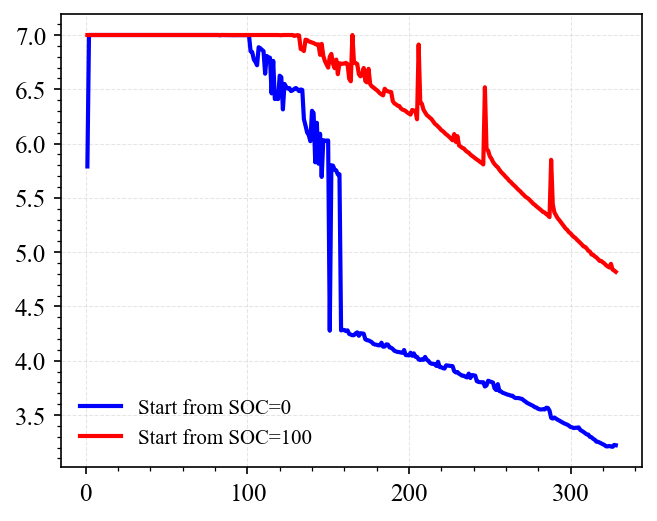

In [19]:
fig,ax = plt.subplots(1,1,figsize=(5,4))
ax.plot(df1["N"],df1["Cn"],'b')
ax.plot(df2["N"],df2["Cn"],'r')
ax.legend(["Start from SOC=0","Start from SOC=100"])

In [20]:
Cna = []
Na = []
x0 = [6,0.01,6,0.9]
for cyc_no in tqdm(N_0):
    # try:
        cyc_data_raw1 = dfo_0[dfo_0["N"] == cyc_no]
        Q_d = cyc_data_raw1["Q"].values
        V_d = cyc_data_raw1["V"].values
        Q_d1 = Q_d[::5]
        V_d = V_d[::5]
        Qmax = max(Q_d)
        Q_d2 = Qmax - Q_d1
        if cyc_no >1:
            x0 = [np.average(Cna[-2:]),np.average(xa[-2:]),np.average(Cpa[-2:]),np.average(ya[-2:])]
        result = minimize(fitfunc1, x0, args=(Q_d1,V_d,R,0), bounds=bounds)
        res = result.x
        Na = np.append(Na,cyc_no)
        Cna = np.append(Cna,res[0])
        xa = np.append(xa,res[1])
        Cpa = np.append(Cpa,res[2])
        ya = np.append(ya,res[3])
df12 = pd.DataFrame({"N":Na,"Cn":Cna})

100%|██████████| 9/9 [00:18<00:00,  2.10s/it]


In [21]:
Cna = []
Na = []
x0 = [6,0.01,6,0.9]
for cyc_no in tqdm(N_0):
    # try:
        cyc_data_raw1 = dfo_0[dfo_0["N"] == cyc_no]
        Q_d = cyc_data_raw1["Q"].values
        V_d = cyc_data_raw1["V"].values
        Q_d1 = Q_d[::5]
        V_d = V_d[::5]
        Qmax = max(Q_d)
        Q_d2 = Qmax - Q_d1
        if cyc_no >1:
            x0 = [np.average(Cna[-2:]),np.average(xa[-2:]),np.average(Cpa[-2:]),np.average(ya[-2:])]
        result = minimize(fitfunc2, x0, args=(Q_d2,V_d,R,0), bounds=bounds)
        res = result.x
        Na = np.append(Na,cyc_no)
        Cna = np.append(Cna,res[0])
        xa = np.append(xa,res[1])
        Cpa = np.append(Cpa,res[2])
        ya = np.append(ya,res[3])
df22 = pd.DataFrame({"N":Na,"Cn":Cna})

100%|██████████| 9/9 [00:37<00:00,  4.16s/it]


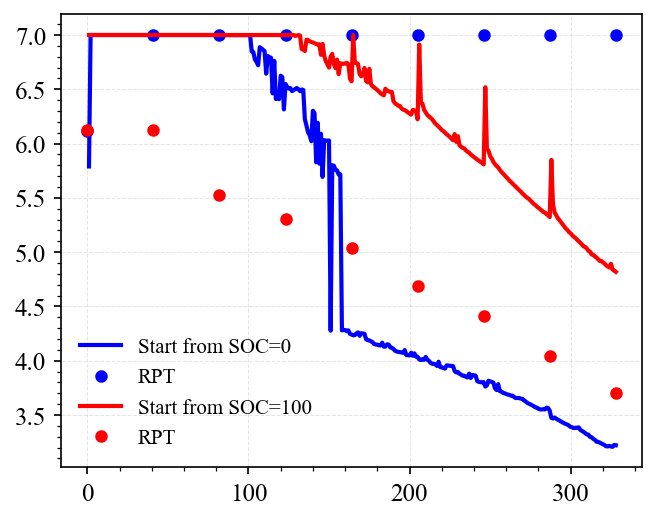

In [22]:
fig,ax = plt.subplots(1,1,figsize=(5,4))
ax.plot(df1["N"],df1["Cn"],'b')
ax.plot(df12["N"],df12["Cn"],'bo')
ax.plot(df2["N"],df2["Cn"],'r')
ax.plot(df22["N"],df22["Cn"],'ro')
ax.legend(["Start from SOC=0","RPT","Start from SOC=100","RPT"])

In [23]:
cell = 4
cell_no,dfe,dfe_0,dfo_0,N,N_0 = load_data(cell,eSOH_DIR,oCV_DIR)
cyc_data_raw1 = pd.read_csv(cyc_DIR+'cycling_data_cell_'+cell_no+'.csv')
cyc_data_raw1['Cycle number'] = cyc_data_raw1['Cycle number'] + 1
xa, ya, Cna, Cpa = np.array([]), np.array([]), np.array([]), np.array([])
Na = np.array([])
x0 = [6,0.01,6,0.9]
for cyc_no in tqdm(range(1,max(cyc_data_raw1['Cycle number'])+1)):
# for cyc_no in tqdm(range(1,5)):
    try:
        if cyc_no >1:
            x0 = [np.average(Cna[-10:]),np.average(xa[-10:]),np.average(Cpa[-10:]),np.average(ya[-10:])]
        t_d,V_d,I_d,Q_d1,Q_d2 = load_cycling_data_ch(cyc_data_raw1,cyc_no)
        Q_d1 = Q_d1[::2]
        Q_d2 = Q_d2[::2]
        V_d = V_d[::2]
        R = dfe_0.iloc[(dfe_0['N']-cyc_no).abs().argsort()[:1]]["Rs_ave"].iloc[0]
        Crate = 1/5
        result = minimize(fitfunc1, x0, args=(Q_d1,V_d,R,Crate), bounds=bounds)
        res = result.x
        Na = np.append(Na,cyc_no)
        Cna = np.append(Cna,res[0])
        xa = np.append(xa,res[1])
        Cpa = np.append(Cpa,res[2])
        ya = np.append(ya,res[3])
    except Exception as error:
        print(cyc_no)
        print(error)
df3 = pd.DataFrame({"N":Na,"Cn":Cna})

100%|██████████| 328/328 [00:40<00:00,  8.07it/s]


In [24]:
cell = 4
cell_no,dfe,dfe_0,dfo_0,N,N_0 = load_data(cell,eSOH_DIR,oCV_DIR)
cyc_data_raw1 = pd.read_csv(cyc_DIR+'cycling_data_cell_'+cell_no+'.csv')
cyc_data_raw1['Cycle number'] = cyc_data_raw1['Cycle number'] + 1
xa, ya, Cna, Cpa = np.array([]), np.array([]), np.array([]), np.array([])
Na = np.array([])
x0 = [6,0.8,6,0.1]
for cyc_no in tqdm(range(1,max(cyc_data_raw1['Cycle number'])+1)):
    try:
        if cyc_no >1:
            x0 = [np.average(Cna[-10:]),np.average(xa[-10:]),np.average(Cpa[-10:]),np.average(ya[-10:])]
        t_d,V_d,I_d,Q_d1,Q_d2 = load_cycling_data_ch(cyc_data_raw1,cyc_no)
        Q_d1 = Q_d1[::2]
        Q_d2 = Q_d2[::2]
        V_d = V_d[::2]
        R = dfe_0.iloc[(dfe_0['N']-cyc_no).abs().argsort()[:1]]["Rs_ave"].iloc[0]
        Crate = 1/5
        result = minimize(fitfunc2, x0, args=(Q_d2,V_d,R,Crate), bounds=bounds)
        res = result.x
        Na = np.append(Na,cyc_no)
        Cna = np.append(Cna,res[0])
        xa = np.append(xa,res[1])
        Cpa = np.append(Cpa,res[2])
        ya = np.append(ya,res[3])
    except Exception as error:
        print(cyc_no)
        print(error)
df4 = pd.DataFrame({"N":Na,"Cn":Cna})

100%|██████████| 328/328 [00:24<00:00, 13.58it/s]


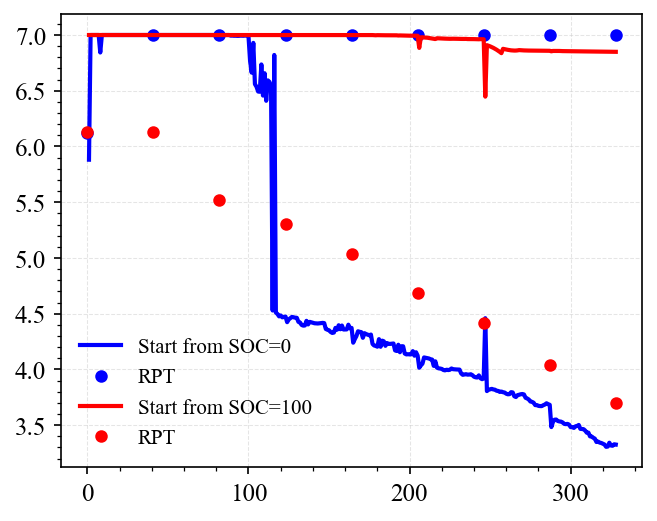

In [25]:
fig,ax = plt.subplots(1,1,figsize=(5,4))
ax.plot(df3["N"],df3["Cn"],'b')
ax.plot(df12["N"],df12["Cn"],'bo')
ax.plot(df4["N"],df4["Cn"],'r')
ax.plot(df22["N"],df22["Cn"],'ro')
ax.legend(["Start from SOC=0","RPT","Start from SOC=100","RPT"])

Text(0, 0.5, '$C_n$')

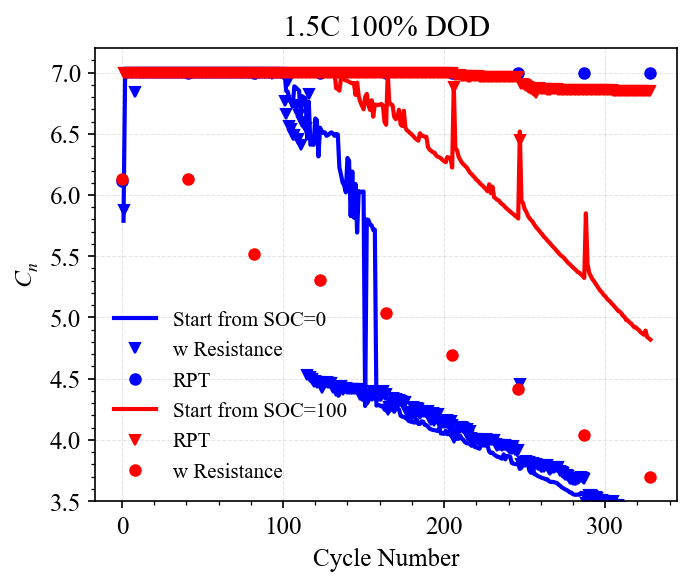

In [34]:
fig,ax = plt.subplots(1,1,figsize=(5,4))
ax.plot(df1["N"],df1["Cn"],'b')
ax.plot(df3["N"],df3["Cn"],'bv')
ax.plot(df12["N"],df12["Cn"],'bo')
ax.plot(df2["N"],df2["Cn"],'r')
ax.plot(df4["N"],df4["Cn"],'rv')
ax.plot(df22["N"],df22["Cn"],'ro')
ax.set_ylim([3.5,7.2])
ax.legend(["Start from SOC=0","w Resistance","RPT","Start from SOC=100","RPT","w Resistance"],loc="lower left")
ax.set_title("1.5C 100% DOD")
ax.set_xlabel("Cycle Number")
ax.set_ylabel(r"$C_n$")